<style>
.shaded-cell {
    background-color: #f0f4f8 !important;
    padding: 15px !important;
    border-radius: 8px !important;
     border-left: 5px solid #3498db
}
</style>

<h1>🚢 Titanic Survival Prediction Analysis </h1>
<h4 style="color:#555; margin-top:-8px;">
Systematic Feature Engineering and Model Optimization for Titanic Survival Prediction</h4>

<hr style="border:1px solid #ddd;">


<div style="background-color:#fff9c4; padding:16px; border-radius:8px; border-left:5px solid #fbc02d;">

<h3>📘Executive Summary</h3>

This project builds an interpretable machine-learning pipeline to predict passenger survival on the Titanic dataset. The work focuses on systematic feature engineering, careful feature selection, and tree-based model optimization to improve predictive performance while maintaining interpretability. Starting from raw passenger records, the project engineers meaningful socio-demographic and structural features (e.g., passenger title, family structure, cabin deck) and evaluates their impact on classification accuracy. The final model achieves ~85% accuracy using Decision Tree models while avoiding data leakage.
</div>


<div style="background-color:pink; padding:16px; border-radius:8px; border-left:5px solid red;">

<h3>🎯 Problem Statement</h3>
The Titanic dataset is a classic binary classification problem where the objective is to predict whether a passenger survived based on demographic, socioeconomic, and travel information. While the dataset is small, it presents real-world challenges:

<ul><li>Missing values (Age, Cabin, Embarked)</li>
    <li>High-cardinality categorical variables (Name, Ticket)</li>
</ul></div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>  📂
    Dataset Overview </h3>
</div>

**Competition:** Titanic: Machine Learning from Disaster  
**File Used:** `train.csv`  
**Dataset Source:** Kaggle  
https://www.kaggle.com/competitions/titanic/data


**Data Source**
* Titanic passenger dataset (Kaggle)

**Raw Features** 
| Feature    | Description                          |
| ---------- | ------------------------------------ |
| `Survived` | Survival indicator (0 = No, 1 = Yes) |
| `Pclass`   | Passenger class (1st, 2nd, 3rd)      |
| `Sex`      | Passenger gender                     |
| `Age`      | Passenger age                        |
| `Fare`     | Ticket fare                          |
| `SibSp`    | Number of siblings/spouses aboard    |
| `Parch`    | Number of parents/children aboard    |
| `Embarked`    | Embarkation Port   |
| `Name`    | Name of the Passenger  |


**Importing the Required Files**

In [255]:
import time
from time import perf_counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from IPython.display import display, Markdown
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score)
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("train.csv") 
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
df.head(3) 
df.tail(3)
pd.Series(df.columns).describe()

count              12
unique             12
top       PassengerId
freq                1
dtype: object

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Age data is available for 714 of the 891 passengers, with a mean age of approximately 30 years and a maximum observed age of 80. Fare values range from 0 to 512, indicating the presence of at least one passenger with a zero or missing fare value. Cabin information is only available for 204 out of 891 records and is therefore excluded from further analysis due to high missingness. Based on initial exploratory review, the Name, Ticket, and Passenger ID variables are also removed, as they are unlikely to provide meaningful predictive value in their raw form
</div>


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 🧹Data Cleaning & Preprocessing</h3>
</div>

**Data Types & Validation**
Numeric and categorical features are verified to ensure correct downstream analysis.
Incorrect data types can lead to invalid probability estimates, scaling errors,
and misleading model behavior. Therefore, explicit data type validation is
performed prior to exploratory analysis and feature engineering

**Inspect Current Data Types**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Explicitly Separate Numeric & Categorical Features**

In [9]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


**Validate Numeric Ranges (Catch Silent Errors)**

In [10]:
df[numeric_features].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Validate Categorical Consistency**

In [11]:
for col in categorical_features:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))


Name unique values:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Sex unique values:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket unique values:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
37

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
Data quality checks are critical to avoid biased probability estimates and
misleading conclusions. Ensuring correct data types prevents numeric operations
from being applied to categorical fields and guarantees that probability
calculations reflect true feature behavior rather than data encoding artifacts.
</div>

**Missing Values**

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [14]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()
df_clean.drop(columns=['passengerid'], inplace=True)
df_clean

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [15]:
df_clean['age'] = df_clean['age'].fillna(df_clean.groupby('sex')['age'].transform('median'))
df_clean['age'].isnull().sum()

np.int64(0)

In [16]:
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean["embarked"].mode()[0])
df_clean['embarked'].isna().sum()

np.int64(0)

In [17]:
df_clean['cabin'] = df_clean['cabin'].fillna('X')

In [27]:
age_bins = [0, 12, 19, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

In [28]:
df_clean['fare_group'] = pd.qcut(df_clean['fare'],q=3,labels=['Low', 'Mid', 'High'])

**Final Quality Check before EDA**

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df_clean.columns

Index(['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked'],
      dtype='object')

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
<ul>
  <li>Added missing <code>Cabin</code> class with X</li>
  <li>Imputed missing <code>Age</code> values using gender-based median imputation</li>
  <li>Addressed missing <code>Embarked</code> values by assigning the most frequent port from existing categories to preserve distribution balance</li>
</ul>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h2>Exploratory Data Analysis</h2>
</div>

### Survival Distribution

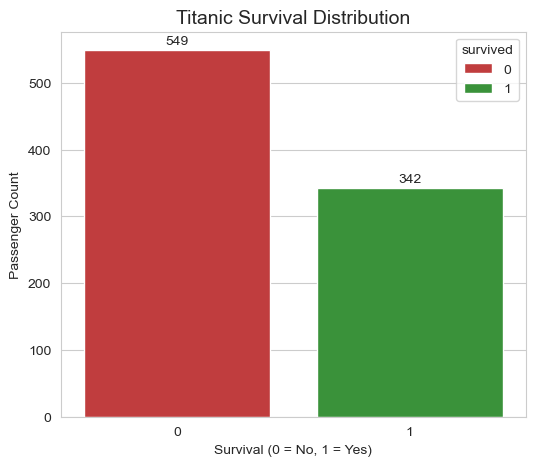

In [47]:
plt.figure(figsize=(6,5))
# Countplot
ax = sns.countplot(x='survived',hue='survived',data=df_clean,palette=['#d62728', '#2ca02c'])
for container in ax.containers:
    ax.bar_label(container, padding=2)
# Title and labels
plt.title("Titanic Survival Distribution", fontsize=14)
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")

plt.show()

### Survival by Gender

In [21]:
survival_by_sex = df_clean.groupby('sex')['survived'].mean()
gender_df = pd.DataFrame({
    'Feature': 'Gender',
    'Group': ['Female', 'Male'],
    'Survival_Probability': [survival_by_sex.iloc[0],survival_by_sex.iloc[1]],
    'Count': [df_clean[df_clean['sex'] == 'female'].shape[0],df_clean[df_clean['sex'] == 'male'].shape[0]]
})
gender_df

,Feature,Group,Survival_Probability,Count
0,Gender,Female,0.742038,314
1,Gender,Male,0.188908,577


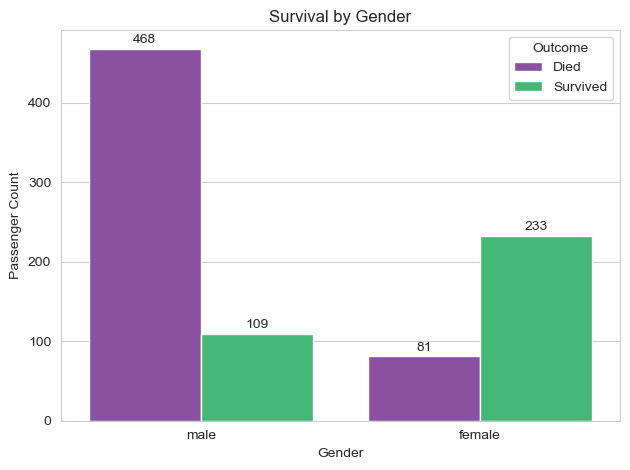

In [51]:
gender_palette = {0: "#8E44AD", 1: "#2ECC71"}
ax = sns.countplot(x='sex',hue='survived',data=df_clean,palette=gender_palette)
ax.set_title("Survival by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Passenger Count")
for container in ax.containers:
    ax.bar_label(container, padding=2)
ax.legend(title='Outcome', labels=['Died', 'Survived'])
plt.tight_layout()    
plt.show()

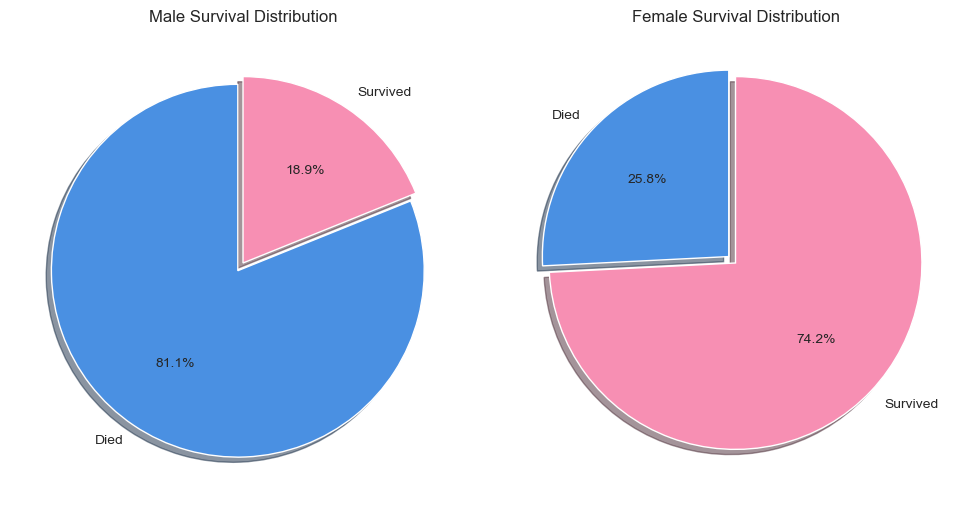

In [52]:
colors = ['#4a90e2', '#f78fb3']  # blue, pink
labels = ['Died', 'Survived']
male_counts = (df.loc[df['Sex'] == 'male', 'Survived'].value_counts().reindex([0, 1], fill_value=0))
female_counts = (df.loc[df['Sex'] == 'female', 'Survived'].value_counts().reindex([0, 1], fill_value=0))
#colors = ['#ff9999', '#66b3ff']   # red-ish / blue-ish
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Male
axes[0].pie(male_counts.values,labels=labels,autopct='%1.1f%%',startangle=90,colors=colors,shadow=True,explode=[0.05, 0])
axes[0].set_title('Male Survival Distribution')
# Female
axes[1].pie(female_counts.values,labels=labels,autopct='%1.1f%%',startangle=90,colors=colors,shadow=True,explode=[0.05, 0])
axes[1].set_title('Female Survival Distribution')

plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
It is striking to observe that the survival rate among females was dramatically higher than that of males. This strongly suggests that evacuation efforts prioritized women during the disaster.
</div>

### Survival by Passenger Class

In [53]:
survival_by_class = df_clean.groupby('pclass')['survived'].mean()
class_df = pd.DataFrame({
    'Feature': 'Passenger Class',
    'Group': ['First', 'Second','Third'],
    'Survival_Probability': [survival_by_class.iloc[0],survival_by_class.iloc[1],survival_by_class.iloc[2]],
    'Count': [df_clean[df_clean['pclass'] == 1].shape[0],df_clean[df_clean['pclass'] == 2].shape[0],df_clean[df_clean['pclass'] == 3].shape[0]]
})
class_df

,Feature,Group,Survival_Probability,Count
0,Passenger Class,First,0.629630,216
1,Passenger Class,Second,0.472826,184
2,Passenger Class,Third,0.242363,491


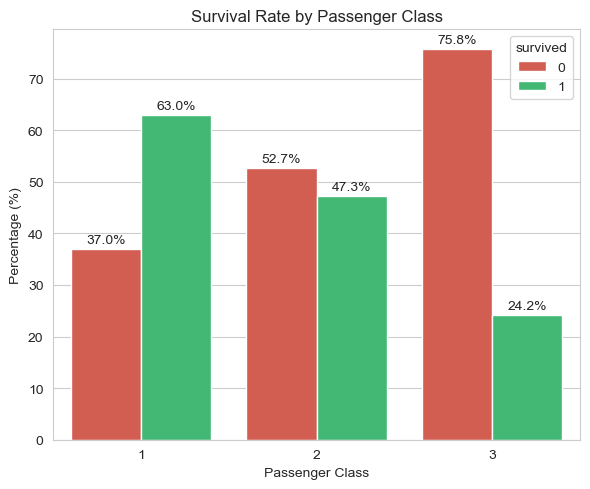

In [56]:
pclass_palette = {0: "#E74C3C",1: "#2ECC71" }
plt.figure(figsize=(6, 5))
counts = ( df_clean.groupby(['pclass', 'survived']).size().reset_index(name='count'))
counts['percent'] = (counts['count'] / counts.groupby('pclass')['count'].transform('sum') * 100)
ax = sns.barplot(x='pclass', y='percent', hue='survived',data=counts,palette=pclass_palette)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Percentage (%)")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Passengers traveling in first class were more likely to survive than those in lower classes, likely reflecting preferential access to evacuation resources</div>

In [57]:
survival_by_age_group = df_clean.groupby('age_group',observed=True)['survived'].mean()
age_df = pd.DataFrame({
    'Feature': 'Age Group',
    'Group': list(survival_by_age_group.keys()),
    'Survival_Probability': survival_by_age_group.values,
    'Count': [
        df_clean[df_clean['age_group'] == group].shape[0]
        for group in survival_by_age_group.keys()
    ]
})
age_df

,Feature,Group,Survival_Probability,Count
0,Age Group,Child,0.579710,69
1,Age Group,Teen,0.410526,95
2,Age Group,Young Adult,0.352941,510
3,Age Group,Adult,0.400000,195
4,Age Group,Senior,0.227273,22


In [61]:
survival_by_fare = (df_clean.groupby('fare_group', observed=True)['survived'].mean())
fare_df = pd.DataFrame({
    'Feature': 'Fare Group',
    'Group': survival_by_fare.index.tolist(),
    'Survival_Probability': survival_by_fare.values,
    'Count': (
        df_clean['fare_group']
        .value_counts()
        .reindex(survival_by_fare.index)
        .values
    )
})
fare_df

,Feature,Group,Survival_Probability,Count
0,Fare Group,Low,0.198052,308
1,Fare Group,Mid,0.402778,288
2,Fare Group,High,0.559322,295


In [62]:
final_probability_df = pd.concat(
    [gender_df, class_df, age_df, fare_df],
    ignore_index=True
)
final_probability_df['Survival_Probability %'] = (final_probability_df['Survival_Probability'] * 100).round(2)


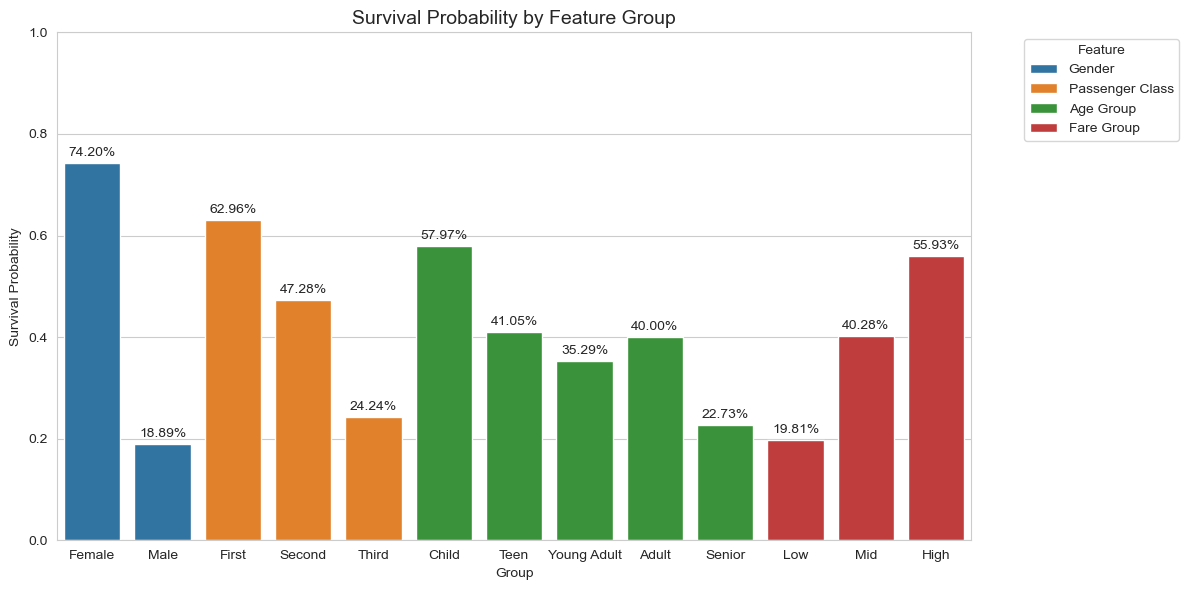

In [63]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=final_probability_df,x='Group',y='Survival_Probability',hue='Feature')
ax.set_title('Survival Probability by Feature Group', fontsize=14)
ax.set_xlabel('Group')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container,labels=[f"{v*100:.2f}%" for v in container.datavalues],padding=3)
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Survival probabilities vary systematically across Age and Fare groups. Younger
passengers and those paying higher fares experienced higher survival likelihood.
These quantified probability patterns reinforce insights from EDA and provide a
strong empirical foundation for downstream logistic regression modelin</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🧠 Feature Engineering</h3>
</div>

Feature engineering is performed to extract additional predictive signal from
existing variables. Rather than relying solely on raw attributes, engineered
features are designed to better reflect social structure, travel context, and
evacuation dynamics observed during the Titanic disaster.


**Family Size**

In [68]:
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

**Alone**

In [69]:
df_clean["alone"] = (df_clean["family_size"] == 1).astype(int)

**Title Extraction from Name - Grouping**

In [70]:
df_clean['title'] = df_clean['name'].str.extract(' ([A-Za-z]+)\.')
df_clean["title"].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [71]:
df_clean["title_group"] = df_clean["title"].replace({
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss","Master": "Master",
    "Ms": "Miss", "Mlle": "Miss","Mme": "Mrs",
    "Dr": "Rare","Rev": "Rare", "Col": "Rare","Major": "Rare","Capt": "Rare","Don": "Rare","Sir": "Rare","Lady": "Rare",
    "Countess": "Rare","Jonkheer": "Rare","Dona": "Rare"})
df_clean["title_group"].value_counts()

title_group
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

**Cabin & Deck Features**

In [72]:
df_clean["cabin"].value_counts()

cabin
X              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [73]:
df_clean['deck']   = df_clean['cabin'].str[0]
df_clean['deck'].value_counts()
df_clean['has_cabin'] = (df_clean['cabin'] != 'X').astype(int)

In [74]:
age_bins = [0, 12, 19, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)
df_clean.columns

Index(['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'age_group', 'fare_group', 'family_size',
       'alone', 'title', 'title_group', 'deck', 'has_cabin'],
      dtype='object')

In [75]:
df_clean['fare_group'] = pd.qcut(df_clean['fare'],q=3,labels=['Low', 'Mid', 'High'])
df_clean.columns

Index(['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'age_group', 'fare_group', 'family_size',
       'alone', 'title', 'title_group', 'deck', 'has_cabin'],
      dtype='object')

In [76]:
df_clean["farePerPerson"] = df_clean["fare"] / df_clean["family_size"]

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>New Features Added:</strong> 
<ul>
    <li>Added Family Size </li>
    <li>Extracted title out of name to classify people </li>
    <li>Added deck column based on cabin. Upon research it seems that there was blank cabin because lower decks don't have cabin. </li>
</ul>
</div>


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>Encoding & Initial Feature Selection</h3>
</div>

In [77]:
df_titanic = df_clean.copy()  # your dataframe name
y = df_titanic["survived"].astype(int)

In [78]:
numeric = df_titanic.select_dtypes(include=['int64','float64']).columns
category = df_titanic.select_dtypes(include=['object']).columns

In [80]:
df_num = df_titanic[numeric].copy()
df_num.drop(columns=['parch','sibsp'],inplace=True)

In [79]:
df_cat= df_titanic[category].copy()
df_cat.drop(columns=['title','name','title_group','ticket','deck','cabin'],inplace=True)

In [82]:
df_encoded = pd.get_dummies(df_cat,drop_first=True)

In [83]:
df_final = pd.concat([df_num, df_encoded], axis=1)

In [84]:
corr = df_final.corr()["survived"].sort_values(ascending=False)

In [36]:
corr_filtered = corr[abs(corr) >= 0.05]
corr_filtered.sort_values(ascending=True)

sex_male        -0.543351
pclass          -0.338481
alone           -0.203367
embarked_S      -0.149683
age             -0.073296
farePerPerson    0.221600
fare             0.257307
has_cabin        0.316912
survived         1.000000
Name: survived, dtype: float64

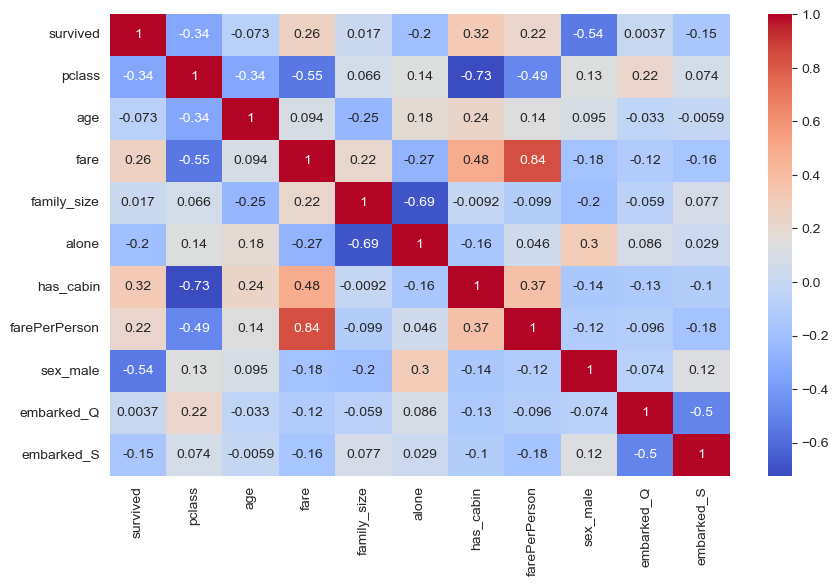

In [88]:
plt.figure(figsize=(10,6))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm')
plt.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Hyperparameter Scaling</h3>
</div>

This function dynamically scales Decision Tree hyperparameters based on the training dataset size. It estimates an appropriate maximum depth using log2(n) and sets min_samples_split and min_samples_leaf as percentages of the training data to ensure statistically meaningful splits. It then iterates through combinations of these scaled parameters, evaluates performance on a test set, and returns the best-performing configuration to balance model complexity and overfitting.

In [89]:
def optimize_decision_tree_hyperparameters (X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    n_train = X_train.shape[0]

    """
    1. Choosing the Maximum Depth 
    It requires a node to contain 1–3% of the training data before it can split.
    The maximum depth is estimated using log₂(n), which aligns with the binary splitting nature of trees.
    A narrow range around this value is explored to efficiently tune depth while preventing overfitting.
    """
    max_depth = int(np.ceil(np.log2(n_train)))
    depths = list(range(max(2, max_depth - 3), max_depth + 2))
    """
    2. Minimum Samples Required to Split a Node
    A node must contain <strong>1–3% of the training data</strong> before it can split.
    This reduces noisy splits and ensures statistical significance at each decision point.
    """
    splits = [max(2, int(0.01 * n_train)), max(2, int(0.02 * n_train)), max(2, int(0.03 * n_train))]
    #It enforces that each final decision represents at least 0.5–2% of the data.
    """
    3. Minimum Samples per Leaf Node
    Each leaf node is required to represent at least 0.5–2% of the data, ensuring stable
    predictions and preventing overfitting to very small populations.
    """
    leaves =  [max(1, int(0.005 * n_train)),  max(1, int(0.01 * n_train)), max(1, int(0.02 * n_train))]
    best_acc = 0
    for depth in depths:
        for split in splits:
            for leaf in leaves:
                model = DecisionTreeClassifier(max_depth=depth,min_samples_split=split, min_samples_leaf=leaf,random_state=42)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                if acc > best_acc:
                    best_acc = acc
                    param = (depth, split, leaf)
    return param 

In [90]:
def optimize_knn_hyperparameters():
    return 7 

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Model Evaluation</h3>
</div>

In [256]:
def run_model(cols, encoding_cols, model_name, df=df_titanic, y=y,test_size=0.2, random_state=42, drop_first=True,eval=False):
    X = df[cols].copy()
    if encoding_cols:
        X = pd.get_dummies(X, columns=encoding_cols, drop_first=drop_first)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    depth, split, leaf,knn_n = 0,0,0,0 
            
    if model_name == "Decision Tree":
        depth, split, leaf = optimize_decision_tree_hyperparameters(X,y) 
    elif model_name == "KNN":
        knn_n = optimize_knn_hyperparameters()
    
    rf_n,rf_d,rf_s,rf_l = 700,10,2,1
    
    xgb_params = dict(n_estimators=400,learning_rate=0.05,max_depth=3,subsample=0.9,colsample_bytree=0.9,
                      reg_lambda=1.0,random_state=42,eval_metric="logloss",n_jobs=-1)
    
    base_models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=depth, min_samples_split=split, min_samples_leaf=leaf, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=rf_n, max_depth=rf_d, min_samples_split=rf_s, min_samples_leaf=rf_l,n_jobs=-1, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=knn_n),
        "SVM": SVC(kernel="linear",random_state=42),
        "Logistic Regression": LogisticRegression(solver="liblinear", random_state=42,),
        "XGBoost": XGBClassifier(**xgb_params), 
    }
    if model_name not in base_models:
        raise ValueError(f"Unknown model_name '{model_name}'. Choose from: {list(base_models.keys())}")

    print(f"{model_name} model trained successfully.")
    print("Making predictions on the test set...")   
    
    model = base_models[model_name]
    needs_scaling = model_name in {"SVM","KNN"}
    if needs_scaling:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        model.fit(X_train_scaled,y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

    if eval:
        model_evaluation(model_name,y_test,y_pred) 
    else:
        print(f"{model_name} Accuracy: {acc:.4f}")
    return acc


In [252]:
def model_evaluation(model_name,y_test,y_pred):
    
    cm = confusion_matrix(y_test, y_pred)  
    tn, fp, fn, tp = cm.ravel()
    labels = [
    [f'True Negatives\n(TN)\n{tn:,}', f'False Positives\n(FP)\n{fp:,}'],
    [f'False Negatives\n(FN)\n{fn:,}', f'True Positives\n(TP)\n{tp:,}']]
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=False, cmap='Blues',xticklabels=['Predicted Died', 'Predicted Survived'],yticklabels=['Actual Died', 'Actual Survived'])
    plt.text(0.5, 0.5, labels[0][0], ha='center', va='center',fontsize=10, color='darkblue', fontweight='bold')
    plt.text(1.5, 0.5, labels[0][1], ha='center', va='center', fontsize=10, color='red', fontweight='bold')
    plt.text(0.5, 1.5, labels[1][0], ha='center', va='center',fontsize=10, color='red', fontweight='bold')
    plt.text(1.5, 1.5, labels[1][1], ha='center', va='center',fontsize=10, color='darkgreen', fontweight='bold')
    plt.title("Confusion Matrix using "+model_name)
    plt.show()

    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).T
    # Rename rows for clarity
    report_df.rename(index={'0': 'Died (0)','1': 'Survived (1)','macro avg': 'Macro Avg','weighted avg': 'Weighted Avg'}, inplace=True)    
    accuracy = report_df.loc['accuracy', 'precision']
    report_df = report_df.drop(index='accuracy')
    report_df = report_df.round(3)
    
    # Style it
    styled_report = (report_df.style
        .format({
            "precision": "{:.2f}",
            "recall": "{:.2f}",
            "f1-score": "{:.2f}",
            "support": "{:.0f}"
        })
        .background_gradient(cmap="Blues", subset=["precision", "recall", "f1-score"])
        .set_caption(" Classification Report")
    )
    
    display(styled_report)    
    display(Markdown(f"### 🎯 Overall Accuracy: **{accuracy:.2%}**\n"))

**Logistic Regression**

In [242]:
cols = ["sex","age","pclass","embarked","fare","family_size"]
encoding_cols = ["sex","pclass","embarked"]
accuracy_log_reg = run_model(cols,encoding_cols,"Logistic Regression")

Logistic Regression model trained successfully.
Making predictions on the test set...
Logistic Regression Accuracy: 0.7933


**Decision Tree Classifer**

In [243]:
cols = ["sex","age","pclass","embarked","fare","family_size","alone"]
encoding_cols = ["sex","pclass","embarked"]
accuracy_dt = run_model(cols,encoding_cols,"Decision Tree")

Decision Tree model trained successfully.
Making predictions on the test set...
Decision Tree Accuracy: 0.8715


**Random Forest Analysis**

In [244]:
cols = ["sex","age","pclass","embarked","fare","family_size","alone"]
encoding_cols = ["sex","pclass","embarked"]
accuracy_rf = run_model(cols,encoding_cols,"Random Forest")

Random Forest model trained successfully.
Making predictions on the test set...
Random Forest Accuracy: 0.8212


**K Nearest Neighbors**

In [245]:
cols = ["pclass","embarked","fare","sex","age","family_size","alone","title","has_cabin","farePerPerson"]
encoding_cols = ["embarked","pclass","sex","title"]
accuracy_knn = run_model(cols,encoding_cols,"KNN")

KNN model trained successfully.
Making predictions on the test set...
KNN Accuracy: 0.8492


**SVM**

In [246]:
cols = ["pclass","embarked","fare","sex","age","family_size","alone","title"]
encoding_cols = ["embarked","pclass","sex","title"]
accuracy_svm = run_model(cols,encoding_cols,"SVM")

SVM model trained successfully.
Making predictions on the test set...
SVM Accuracy: 0.8212


**XGBoost Classifier**

In [266]:
cols = ["pclass","embarked","fare","sex","age","family_size","alone","title"]
encoding_cols = ["embarked","pclass","sex","title"]
accuracy_xgb = run_model(cols, encoding_cols, "XGBoost")

XGBoost model trained successfully.
Making predictions on the test set...
XGBoost Accuracy: 0.8436


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Optimized Accuracy for Each Model </h3>
</div>

In [267]:
model_accuracies = {
    'Logistic Regression': accuracy_log_reg,
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf,
    'K-Nearest Neighbors': accuracy_knn,
    'Support Vector Machine': accuracy_svm,
    'XGBoost':accuracy_xgb
}
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(Markdown(f"#### 📊 Model Comparison — Accuracy"))
styled_table = (
    accuracy_df.style
        .hide(axis="index") 
        .format({
            "Accuracy": "{:.2%}",
            "Time Complexity": "{:.4f} sec"
        })
        .background_gradient(cmap="Greens", subset=["Accuracy"])   
        .set_properties(subset=["Model"], **{"text-align": "left"})
        .set_table_styles([
            {"selector": "caption","props": [("caption-side", "top"),("font-size", "16pt"),("font-weight", "bold"),("text-align", "left"),("padding", "10px")]},
            {"selector": "th","props": [("text-align", "left")]}
        ])
)
accuracy_df.style.hide(axis="index")
display(styled_table)

#### 📊 Model Comparison — Accuracy

Model,Accuracy
Decision Tree,87.15%
K-Nearest Neighbors,84.92%
XGBoost,84.36%
Random Forest,82.12%
Support Vector Machine,82.12%
Logistic Regression,79.33%


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Model Comparison </h3>
</div>

In [268]:
cols = ["pclass","embarked","fare","sex","age","family_size","alone","title"]
encoding_cols = ["embarked","pclass","sex","title"]

In [269]:
def time_complexity(model):
    start = perf_counter()
    m = run_model(cols,encoding_cols,model,eval=True)
    elapsed = perf_counter() - start
    print(f"Took {elapsed:.6f} seconds")
    print("\n")
    return m, elapsed

Logistic Regression model trained successfully.
Making predictions on the test set...


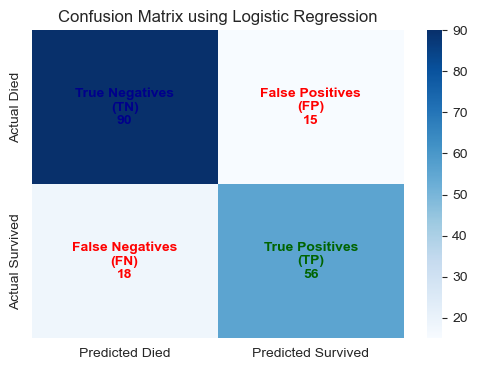

,precision,recall,f1-score,support
Died (0),0.83,0.86,0.84,105
Survived (1),0.79,0.76,0.77,74
Macro Avg,0.81,0.81,0.81,179
Weighted Avg,0.81,0.82,0.81,179


### 🎯 Overall Accuracy: **81.56%**


Took 0.225865 seconds




In [275]:
accuracy_log_reg = time_complexity("Logistic Regression")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> Logistic Regression Model Summary: </strong><br>
The Logistic Regression model achieved an overall accuracy of <strong>81.56%</strong>, correctly classifying 146 out of 179 passengers. The model produced 33 total misclassifications, including 15 false positives and 18 false negatives.
For the survival class, Logistic Regression achieved <strong>79% precision</strong> and <strong>76% recall</strong>, indicating balanced performance but with approximately 24% of actual survivors misclassified. The macro F1-score of <strong>0.81</strong> reflects consistent performance across both classes.
While Logistic Regression provides stable and interpretable results, its accuracy and recall are slightly lower compared to the Decision Tree model, making it a solid baseline model rather than the top performer.
</div>

Decision Tree model trained successfully.
Making predictions on the test set...


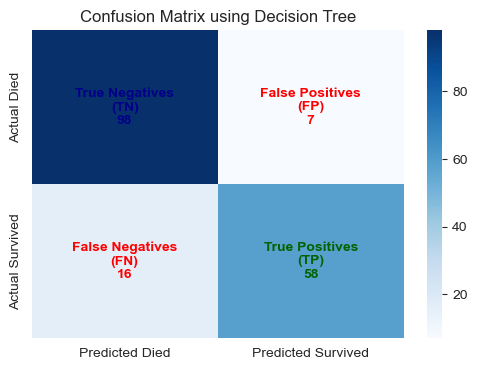

,precision,recall,f1-score,support
Died (0),0.86,0.93,0.90,105
Survived (1),0.89,0.78,0.83,74
Macro Avg,0.88,0.86,0.86,179
Weighted Avg,0.87,0.87,0.87,179


### 🎯 Overall Accuracy: **87.15%**


Took 0.399895 seconds




In [276]:
accuracy_dt = time_complexity("Decision Tree")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> Decision Tree Model Summary: </strong><br>
The Decision Tree model achieved the highest performance among the evaluated models, with an overall accuracy of <strong>87.15%</strong>, correctly classifying 156 out of 179 passengers. The model produced 23 total misclassifications, including 7 false positives and 16 false negatives.

For the survival class, the model achieved <strong>89% precision</strong> and <strong>78% recall</strong>, meaning it made reliable survival predictions while correctly identifying the majority of actual survivors. The macro F1-score of <strong>0.86</strong> reflects strong and balanced performance across both classes.

Compared to Logistic Regression, KNN, and SVM, the Decision Tree demonstrates superior accuracy and improved recall, making it the top-performing model in this comparison
</div>

Random Forest model trained successfully.
Making predictions on the test set...


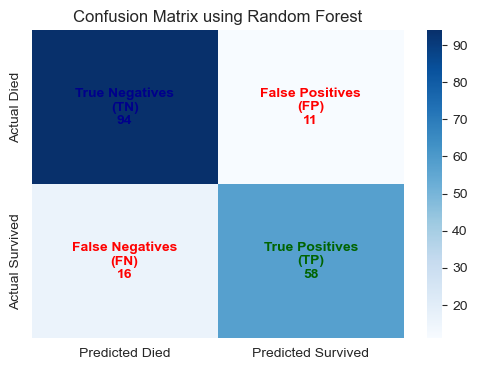

,precision,recall,f1-score,support
Died (0),0.85,0.90,0.87,105
Survived (1),0.84,0.78,0.81,74
Macro Avg,0.85,0.84,0.84,179
Weighted Avg,0.85,0.85,0.85,179


### 🎯 Overall Accuracy: **84.92%**


Took 1.361447 seconds




In [277]:
accuracy_rf = time_complexity("Random Forest")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> Rnadom Forest Model Summary: </strong><br>
The Random Forest model achieved an overall accuracy of <strong>84.92%</strong>, correctly classifying 152 out of 179 passengers. The model produced 27 total misclassifications, including 11 false positives and 16 false negatives.

For the survival class, Random Forest achieved <strong>84% precision</strong> and <strong>78% recall</strong>, indicating reliable survival predictions while correctly identifying the majority of actual survivors. The macro F1-score of <strong>0.84</strong> reflects strong and balanced performance across both classes.

Compared to Logistic Regression, SVM, and KNN, Random Forest demonstrates improved accuracy and better class balance. However, it slightly underperforms the Decision Tree model in overall accuracy while typically offering better generalization due to its ensemble nature.
</div>

KNN model trained successfully.
Making predictions on the test set...


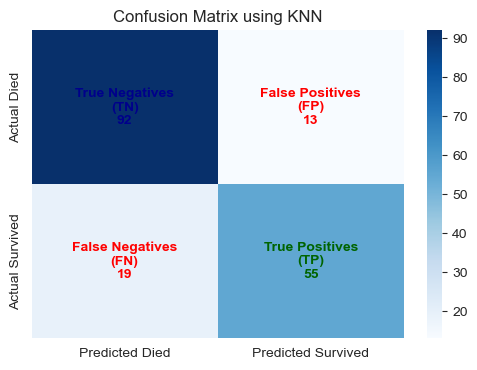

,precision,recall,f1-score,support
Died (0),0.83,0.88,0.85,105
Survived (1),0.81,0.74,0.78,74
Macro Avg,0.82,0.81,0.81,179
Weighted Avg,0.82,0.82,0.82,179


### 🎯 Overall Accuracy: **82.12%**


Took 0.208467 seconds




In [278]:
accuracy_knn = time_complexity("KNN")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> KNN Model Summary: </strong><br>
The K-Nearest Neighbors (KNN) model achieved an overall accuracy of <strong>82.12%</strong>, correctly classifying 147 out of 179 passengers. The model produced 32 total misclassifications, including 13 false positives and 19 false negatives.

For the survival class, KNN achieved <strong>81% precision</strong> and <strong>74% recall</strong>, indicating that while predictions of survival were generally reliable, approximately 26% of actual survivors were missed. The macro F1-score of <strong>0.81</strong> reflects balanced overall performance across classes.

</div>

SVM model trained successfully.
Making predictions on the test set...


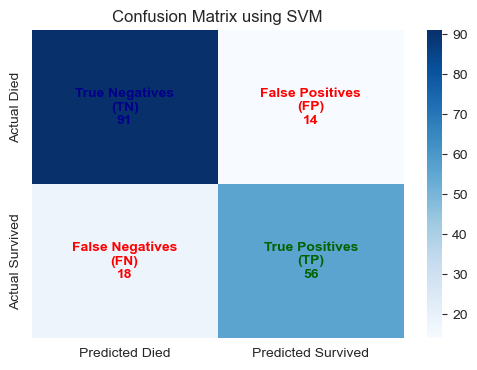

,precision,recall,f1-score,support
Died (0),0.83,0.87,0.85,105
Survived (1),0.80,0.76,0.78,74
Macro Avg,0.82,0.81,0.81,179
Weighted Avg,0.82,0.82,0.82,179


### 🎯 Overall Accuracy: **82.12%**


Took 0.204662 seconds




In [279]:
accuracy_svm = time_complexity("SVM")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> SVM Model Summary: </strong><br>
The Support Vector Machine (SVM) model achieved an overall accuracy of <strong>82.12%</strong>. It correctly classified 147 out of 179 passengers, with 32 total misclassifications (14 false positives and 18 false negatives).

For the survival class, the model achieved <strong>80% precision</strong> and <strong>76% recall</strong>, meaning it correctly identified most survivors but missed approximately 24% of them. Performance across classes is relatively balanced, as reflected by a macro F1-score of <strong>0.81</strong>.

While SVM delivers stable and consistent performance, it underperforms compared to the Decision Tree model (87.15% accuracy) and shows similar recall limitations in identifying survivors.
</div>

### XGBoost ###

XGBoost model trained successfully.
Making predictions on the test set...


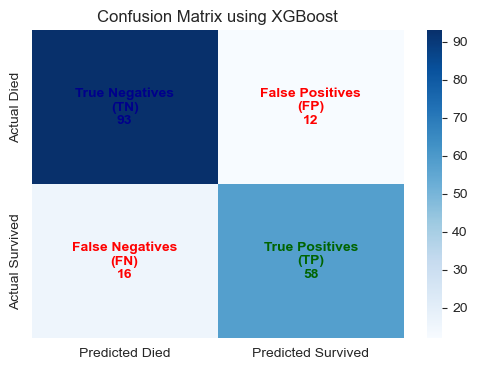

,precision,recall,f1-score,support
Died (0),0.85,0.89,0.87,105
Survived (1),0.83,0.78,0.81,74
Macro Avg,0.84,0.83,0.84,179
Weighted Avg,0.84,0.84,0.84,179


### 🎯 Overall Accuracy: **84.36%**


Took 0.422220 seconds




In [280]:
accuracy_xgb = time_complexity("XGBoost")

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong> XGBoost Model Summary: </strong><br>
The XGBoost model achieved an overall accuracy of <strong>84.36%</strong>, correctly classifying 151 out of 179 passengers. The model produced 28 total misclassifications, including 12 false positives and 16 false negatives.

For the survival class, XGBoost achieved <strong>83% precision</strong> and <strong>78% recall</strong>, meaning survival predictions were reliable while successfully identifying the majority of actual survivors. The macro F1-score of <strong>0.84</strong> reflects strong and balanced performance across both classes.

Compared to Logistic Regression, SVM, and KNN, XGBoost delivers higher accuracy and improved class balance. While it slightly trails the Decision Tree model in overall accuracy (87.15%), it typically offers better robustness and generalization due to its boosted ensemble structure
</div>

### Model Summary ###

In [281]:
model_results = {
    "Logistic Regression": {"Accuracy": accuracy_log_reg[0],"Time Complexity": accuracy_log_reg[1]},
    "Decision Tree": {"Accuracy": accuracy_dt[0],"Time Complexity": accuracy_dt[1]},
    "Random Forest": {"Accuracy": accuracy_rf[0],"Time Complexity": accuracy_rf[1]},
    "K-Nearest Neighbors": {"Accuracy": accuracy_knn[0],"Time Complexity": accuracy_knn[1]},
    "Support Vector Machine": {"Accuracy": accuracy_svm[0],"Time Complexity": accuracy_svm[1]},
    "XGBoost": {"Accuracy": accuracy_xgb[0],"Time Complexity": accuracy_xgb[1]}
} 
accuracy_df = (
    pd.DataFrame.from_dict(model_results, orient="index")
      .reset_index()
      .rename(columns={"index": "Model"})
      .sort_values(by="Time Complexity", ascending=False)
      .reset_index(drop=True)
)

display(Markdown(f"#### 📊 Model Comparison — Accuracy & Time Complexity"))
styled_table = (
    accuracy_df.style
        .hide(axis="index") 
        .format({
            "Accuracy": "{:.2%}",
            "Time Complexity": "{:.4f} sec"
        })
        .background_gradient(cmap="Greens", subset=["Accuracy"])   
        .background_gradient(cmap="Reds", subset=["Time Complexity"])
        .set_properties(subset=["Model"], **{"text-align": "left"})
        .set_table_styles([
            {"selector": "caption","props": [("caption-side", "top"),("font-size", "16pt"),("font-weight", "bold"),("text-align", "left"),("padding", "10px")]},
            {"selector": "th","props": [("text-align", "left")]}
        ])
)
accuracy_df.style.hide(axis="index")
display(styled_table)


#### 📊 Model Comparison — Accuracy & Time Complexity

Model,Accuracy,Time Complexity
Random Forest,84.92%,1.3614 sec
XGBoost,84.36%,0.4222 sec
Decision Tree,87.15%,0.3999 sec
Logistic Regression,81.56%,0.2259 sec
K-Nearest Neighbors,82.12%,0.2085 sec
Support Vector Machine,82.12%,0.2047 sec


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Optimal Solution </h3>
</div>

In [282]:
depth, split, leaf = 11,7,7
cols = ["pclass","embarked","fare","sex","age","family_size","alone","title"]
encoding_cols = ["embarked","pclass","sex","title"]
X = df_titanic[cols]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#model = DecisionTreeClassifier(random_state=42)
model = DecisionTreeClassifier(max_depth=depth,min_samples_split=split, min_samples_leaf=leaf,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [283]:
print(f"Accuracy Achieved = {accuracy_score(y_test, y_pred)*100:.2f} %")

Accuracy Achieved = 87.15 %


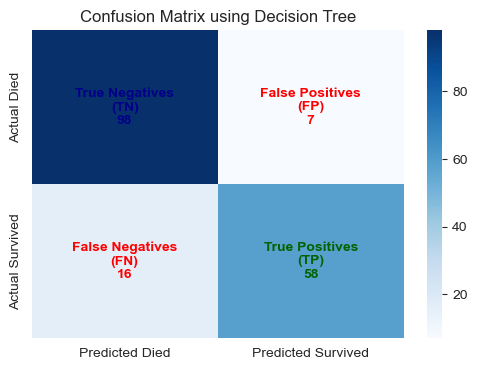

,precision,recall,f1-score,support
Died (0),0.86,0.93,0.90,105
Survived (1),0.89,0.78,0.83,74
Macro Avg,0.88,0.86,0.86,179
Weighted Avg,0.87,0.87,0.87,179


### 🎯 Overall Accuracy: **87.15%**


In [284]:
model_evaluation("Decision Tree",y_test,y_pred)

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong><br>
The model achieved <strong>87.15% accuracy</strong> with strong precision (<strong>89%</strong>) and balanced recall (<strong>78%</strong>) for the survival class.
Only 16 out of 74 actual survivors were misclassified (~22%), indicating solid performance with room for further improvement through ensemble methods or hyperparameter tuning.
</div>

**Plotting the Decision Tree**

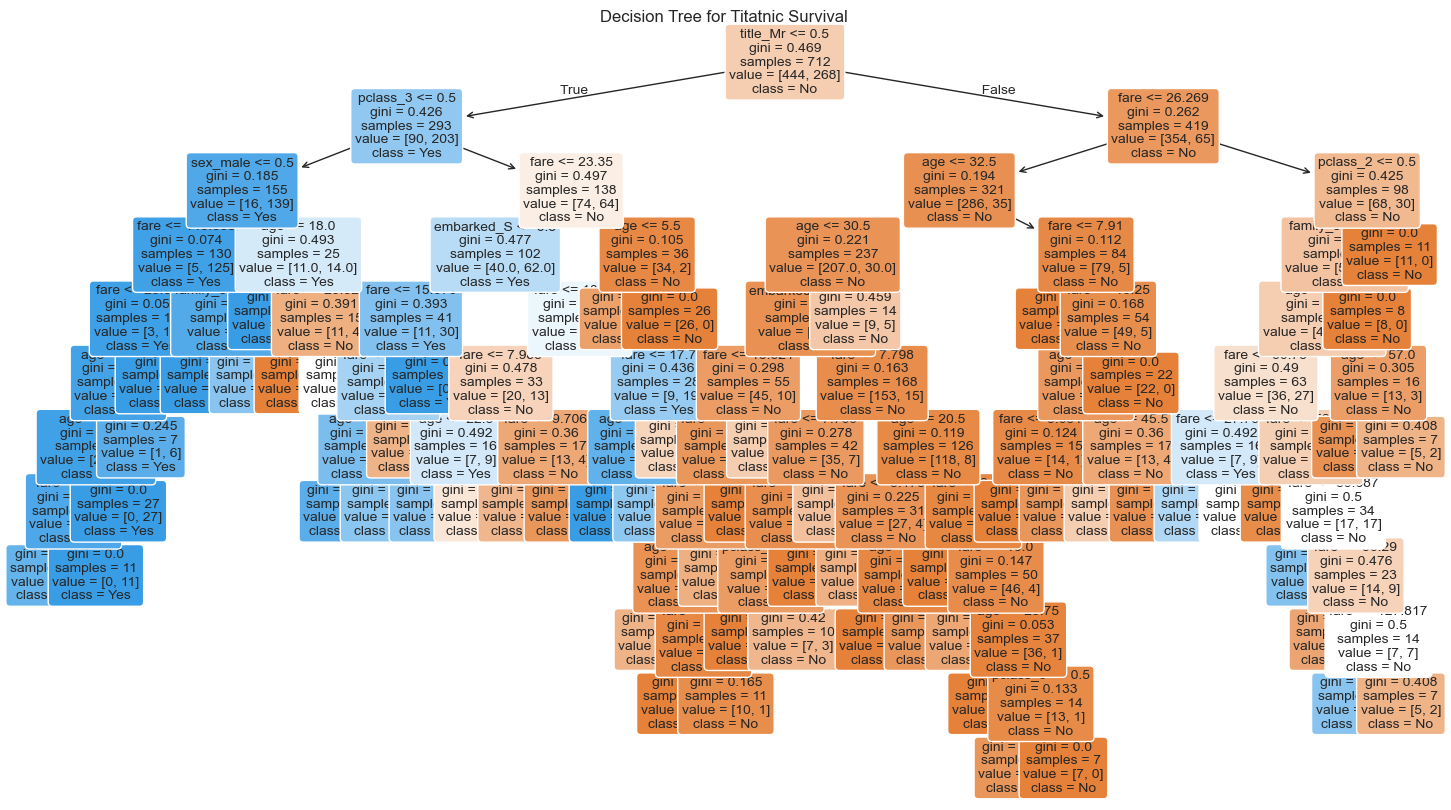

In [285]:
plt.figure(figsize=(18, 10))
plot_tree(model,feature_names=X.columns,class_names=['No', 'Yes'],   filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree for Titatnic Survival ")
plt.savefig("dt.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📌 Final Summary</h3></div>


<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
This project applies a Decision Tree classifier to predict passenger survival on the Titanic dataset, with a strong emphasis on feature engineering and model interpretability. Starting from raw passenger records, the project addresses missing data, categorical encoding, and feature redundancy to improve predictive performance while avoiding data leakage. Key engineered features include passenger title groups derived from names, family structure indicators, cabin deck information, and log-transformed fare values. Decision Tree hyperparameters such as maximum depth, minimum samples per split, and minimum samples per leaf were systematically tuned to balance bias and variance. The final optimized model achieves <strong> ~87.15% accuracy </strong>, demonstrating that careful feature selection and tree regularization can substantially improve performance while preserving explainability.
</ul>
</div>
